In [26]:
# ============================================================
# CELL 1 — Mount Drive + Configuration
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ── ONLY THING YOU NEED TO CHANGE ──
USE_DEV_SAMPLE = False   # True = 50K dev sample (free Colab). False = full data (Colab Pro)
# ────────────────────────────────────

# ── Auto-detect Drive path (works for both Ruby and Oscar) ──
_possible_paths = [
    '/content/drive/MyDrive/Capstone/Capstone_IoT',  # Oscar
    '/content/drive/MyDrive/Capstone_IoT',           # Ruby
]
BASE = next((p for p in _possible_paths if os.path.exists(p)), None)
if BASE is None:
    raise FileNotFoundError("Could not find Capstone_IoT folder. Check your Drive path.")
# ────────────────────────────────────────────────────────────

PROCESSED  = os.path.join(BASE, 'Data/Processed')
RES_L3     = os.path.join(BASE, 'Results/Layer3')
RES_L4     = os.path.join(BASE, 'Results/Layer4')
RES_L5     = os.path.join(BASE, 'Results/Layer5')
FIGS_DIR   = os.path.join(BASE, 'Figures')

for d in [RES_L3, RES_L4, RES_L5, FIGS_DIR]:
    os.makedirs(d, exist_ok=True)

RANDOM_SEED = 42
LABEL_COL   = 'Label'
np.random.seed(RANDOM_SEED)

import tensorflow as tf
tf.random.set_seed(RANDOM_SEED)

print(f"Mode : {'DEV_SAMPLE (50K)' if USE_DEV_SAMPLE else 'FULL DATA'}")
print(f"Base : {BASE}")
print("Directories ready ✓")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mode : FULL DATA
Base : /content/drive/MyDrive/Capstone_IoT
Directories ready ✓


In [27]:
# ============================================================
# CELL 2 — Imports
# ============================================================
from sklearn.ensemble        import RandomForestClassifier
from sklearn.cluster         import KMeans
from sklearn.metrics         import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    accuracy_score, precision_score
)
from sklearn.preprocessing   import LabelEncoder
from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier

from tensorflow.keras.models    import Model
from tensorflow.keras.layers    import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

print("All imports OK ✓")

All imports OK ✓


In [28]:
# ============================================================
# CELL 3 — Load parquet splits
# ============================================================

def load_parquet(name):
    path = os.path.join(PROCESSED, name)
    df   = pd.read_parquet(path)
    mb   = os.path.getsize(path) / 1024**2
    print(f"  {name:35s} shape={df.shape}  ({mb:.1f} MB)")
    return df

print("Loading data...")

if USE_DEV_SAMPLE:
    dev     = load_parquet('dev_sample.parquet')
    unknown = load_parquet('unknown_holdout.parquet')
    train_val, test = train_test_split(dev, test_size=0.15,
                                       stratify=dev[LABEL_COL], random_state=RANDOM_SEED)
    train, val      = train_test_split(train_val, test_size=0.1765,
                                       stratify=train_val[LABEL_COL], random_state=RANDOM_SEED)
    print(f"\n[DEV MODE] Sub-splits:  train={train.shape}  val={val.shape}  test={test.shape}")
else:
    train   = load_parquet('train.parquet')
    val     = load_parquet('val.parquet')
    test    = load_parquet('test.parquet')
    unknown = load_parquet('unknown_holdout.parquet')

train   = train.reset_index(drop=True)
val     = val.reset_index(drop=True)
test    = test.reset_index(drop=True)
unknown = unknown.reset_index(drop=True)

FEATURE_COLS = [c for c in train.columns if c != LABEL_COL]

label_encoder = LabelEncoder()
y_train       = label_encoder.fit_transform(train[LABEL_COL])
y_val         = label_encoder.transform(val[LABEL_COL])
y_test        = label_encoder.transform(test[LABEL_COL])
y_unknown_raw = unknown[LABEL_COL].values   # strings, NOT encoded

X_train   = train[FEATURE_COLS].values.astype('float32')
X_val     = val[FEATURE_COLS].values.astype('float32')
X_test    = test[FEATURE_COLS].values.astype('float32')
X_unknown = unknown[FEATURE_COLS].values.astype('float32')

N_CLASSES  = len(label_encoder.classes_)
BENIGN_IDX = int(np.where(label_encoder.classes_ == 'BENIGN')[0][0])

print(f"\nKnown classes      : {N_CLASSES}")
print(f"Benign class index : {BENIGN_IDX}")
print(f"Unknown holdout    : {sorted(set(y_unknown_raw))}")

Loading data...
  train.parquet                       shape=(427077, 40)  (17.8 MB)
  val.parquet                         shape=(91517, 40)  (4.1 MB)
  test.parquet                        shape=(91517, 40)  (4.1 MB)
  unknown_holdout.parquet             shape=(1455, 40)  (0.1 MB)

Known classes      : 29
Benign class index : 0
Unknown holdout    : ['BACKDOOR_MALWARE', 'BROWSERHIJACKING', 'RECON-PINGSWEEP', 'UPLOADING_ATTACK', 'XSS']


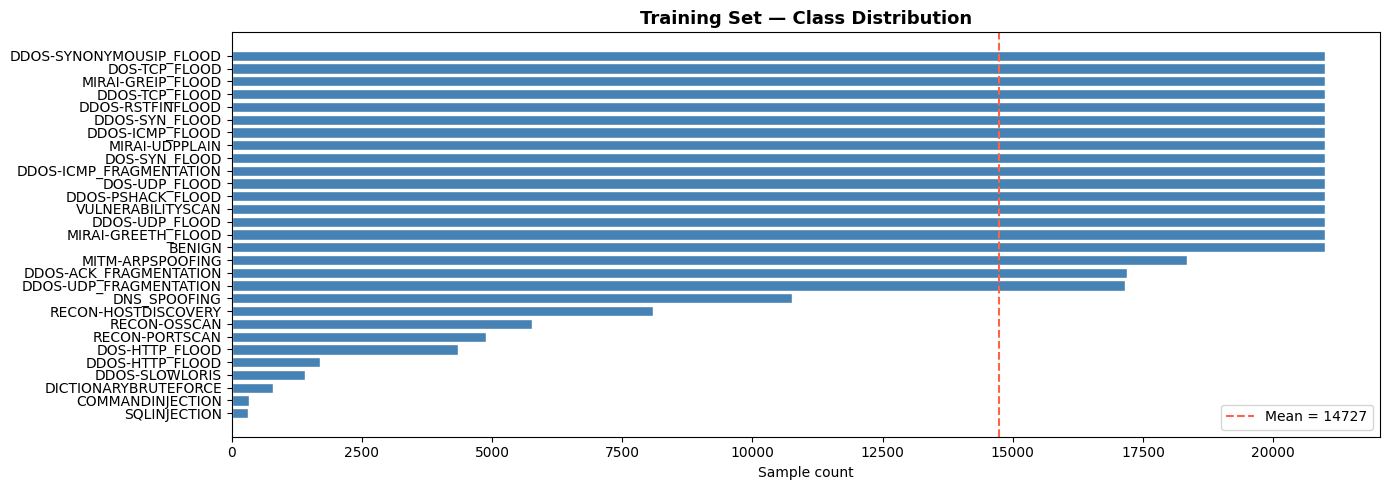

In [29]:
# ============================================================
# CELL 4 — Class distribution chart
# ============================================================

counts = pd.Series(y_train).map(dict(enumerate(label_encoder.classes_))).value_counts()

fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(counts.index[::-1], counts.values[::-1], color='steelblue', edgecolor='white')
ax.axvline(counts.mean(), color='tomato', linestyle='--', label=f'Mean = {counts.mean():.0f}')
ax.set_xlabel('Sample count')
ax.set_title('Training Set — Class Distribution', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'class_distribution.png'), dpi=150)
plt.show()

In [30]:
# ============================================================
# CELL 5 — Layer 3: Random Forest
# ============================================================

print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=200, n_jobs=-1,
                             random_state=RANDOM_SEED, class_weight='balanced')
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1m = f1_score(y_test, rf_pred, average='macro',    zero_division=0)
rf_f1w = f1_score(y_test, rf_pred, average='weighted', zero_division=0)

print(f"\nRandom Forest | Accuracy: {rf_acc:.4f} | F1-macro: {rf_f1m:.4f} | F1-weighted: {rf_f1w:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=label_encoder.classes_, zero_division=0))

json.dump({'model':'RF','accuracy':rf_acc,'f1_macro':rf_f1m,'f1_weighted':rf_f1w},
          open(os.path.join(RES_L3,'rf_metrics.json'),'w'), indent=2)
print(f"Saved → {RES_L3}/rf_metrics.json")

Training Random Forest...

Random Forest | Accuracy: 0.7778 | F1-macro: 0.7014 | F1-weighted: 0.7736

Classification Report:
                         precision    recall  f1-score   support

                 BENIGN       0.67      0.79      0.72      4500
       COMMANDINJECTION       1.00      0.21      0.35        70
 DDOS-ACK_FRAGMENTATION       0.99      0.99      0.99      3686
        DDOS-HTTP_FLOOD       0.87      0.77      0.81       363
        DDOS-ICMP_FLOOD       1.00      1.00      1.00      4500
DDOS-ICMP_FRAGMENTATION       0.98      0.99      0.99      4500
      DDOS-PSHACK_FLOOD       1.00      1.00      1.00      4500
       DDOS-RSTFINFLOOD       1.00      1.00      1.00      4500
         DDOS-SLOWLORIS       0.77      0.92      0.84       302
DDOS-SYNONYMOUSIP_FLOOD       0.48      0.49      0.49      4500
         DDOS-SYN_FLOOD       0.42      0.40      0.41      4500
         DDOS-TCP_FLOOD       0.60      0.57      0.58      4500
         DDOS-UDP_FLOOD      

In [31]:
# ============================================================
# CELL 6 — Layer 3: XGBoost
# ============================================================

print("Training XGBoost...")
xgb = XGBClassifier(objective='multi:softprob', eval_metric='mlogloss',
                     max_depth=6, n_estimators=200, tree_method='hist',
                     random_state=RANDOM_SEED, n_jobs=-1, verbosity=0)
xgb.fit(X_train, y_train)
xgb_pred  = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1m = f1_score(y_test, xgb_pred, average='macro',    zero_division=0)
xgb_f1w = f1_score(y_test, xgb_pred, average='weighted', zero_division=0)

print(f"\nXGBoost | Accuracy: {xgb_acc:.4f} | F1-macro: {xgb_f1m:.4f} | F1-weighted: {xgb_f1w:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=label_encoder.classes_, zero_division=0))

json.dump({'model':'XGBoost','accuracy':xgb_acc,'f1_macro':xgb_f1m,'f1_weighted':xgb_f1w},
          open(os.path.join(RES_L3,'xgb_metrics.json'),'w'), indent=2)
print(f"Saved → {RES_L3}/xgb_metrics.json")

Training XGBoost...

XGBoost | Accuracy: 0.7876 | F1-macro: 0.7049 | F1-weighted: 0.7817

Classification Report:
                         precision    recall  f1-score   support

                 BENIGN       0.69      0.80      0.74      4500
       COMMANDINJECTION       0.69      0.26      0.38        70
 DDOS-ACK_FRAGMENTATION       0.99      0.99      0.99      3686
        DDOS-HTTP_FLOOD       0.72      0.72      0.72       363
        DDOS-ICMP_FLOOD       1.00      1.00      1.00      4500
DDOS-ICMP_FRAGMENTATION       0.99      0.99      0.99      4500
      DDOS-PSHACK_FLOOD       1.00      1.00      1.00      4500
       DDOS-RSTFINFLOOD       1.00      1.00      1.00      4500
         DDOS-SLOWLORIS       0.79      0.84      0.82       302
DDOS-SYNONYMOUSIP_FLOOD       0.47      0.55      0.51      4500
         DDOS-SYN_FLOOD       0.47      0.28      0.35      4500
         DDOS-TCP_FLOOD       0.67      0.55      0.60      4500
         DDOS-UDP_FLOOD       0.70      0

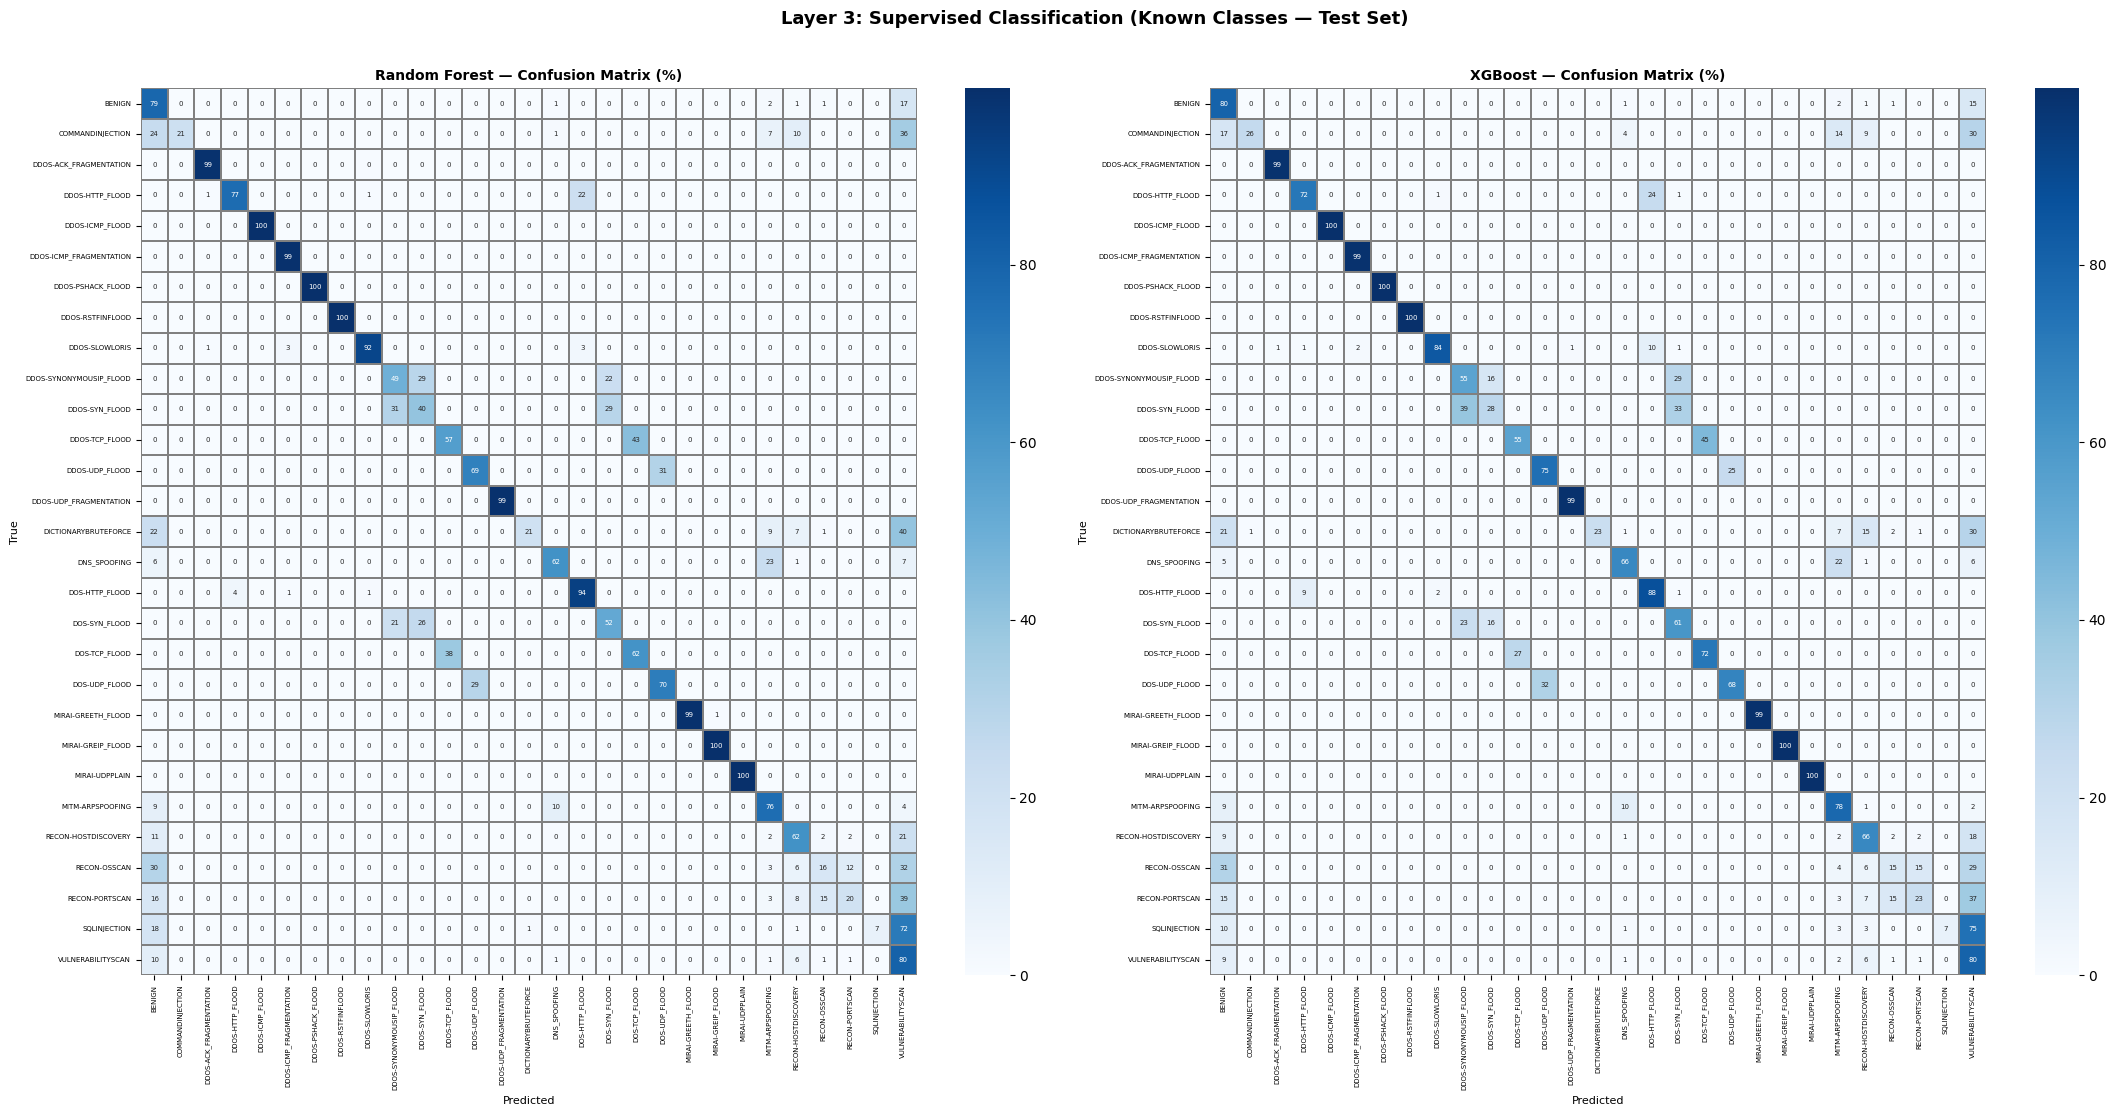

In [32]:
# ============================================================
# CELL 7 — Confusion matrices: RF vs XGBoost
# ============================================================

def plot_cm(y_true, y_pred, title, ax, classes):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_norm, ax=ax, cmap='Blues', fmt='.0f', annot=True,
                xticklabels=classes, yticklabels=classes,
                linewidths=0.3, linecolor='grey', annot_kws={'size': 5})
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True', fontsize=8)
    ax.tick_params(axis='both', labelsize=5)

fig, axes = plt.subplots(1, 2, figsize=(22, 11))
plot_cm(y_test, rf_pred,  'Random Forest — Confusion Matrix (%)',  axes[0], label_encoder.classes_)
plot_cm(y_test, xgb_pred, 'XGBoost — Confusion Matrix (%)',        axes[1], label_encoder.classes_)
plt.suptitle('Layer 3: Supervised Classification (Known Classes — Test Set)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'L3_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

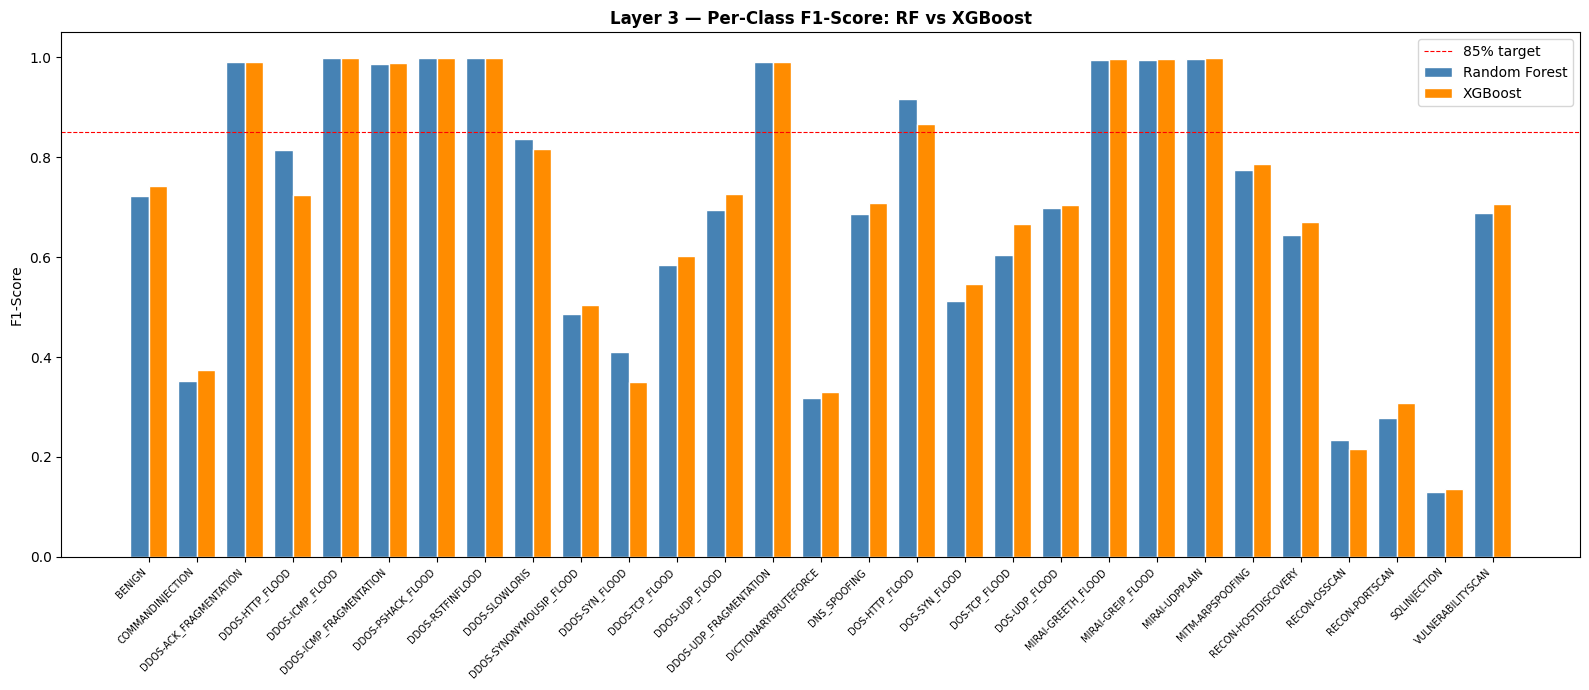

In [33]:
# ============================================================
# CELL 8 — Per-class F1: RF vs XGBoost
# ============================================================

from sklearn.metrics import classification_report as cr

rf_rep  = cr(y_test, rf_pred,  target_names=label_encoder.classes_, output_dict=True, zero_division=0)
xgb_rep = cr(y_test, xgb_pred, target_names=label_encoder.classes_, output_dict=True, zero_division=0)

classes = list(label_encoder.classes_)
rf_f1s  = [rf_rep[c]['f1-score']  for c in classes]
xgb_f1s = [xgb_rep[c]['f1-score'] for c in classes]
x, w    = np.arange(len(classes)), 0.38

fig, ax = plt.subplots(figsize=(16, 7))
ax.bar(x - w/2, rf_f1s,  width=w, label='Random Forest', color='steelblue',  edgecolor='white')
ax.bar(x + w/2, xgb_f1s, width=w, label='XGBoost',       color='darkorange', edgecolor='white')
ax.axhline(0.85, color='red', linestyle='--', linewidth=0.8, label='85% target')
ax.set_xticks(x); ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('F1-Score'); ax.set_ylim(0, 1.05)
ax.set_title('Layer 3 — Per-Class F1-Score: RF vs XGBoost', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'L3_f1_comparison.png'), dpi=150)
plt.show()

In [34]:
# ============================================================
# CELL 9 — Layer 4: Autoencoder (benign samples only)
# Architecture: 39→64→32→64→39  (Oscar's original)
# ============================================================

benign_train_mask = (y_train == BENIGN_IDX)
benign_val_mask   = (y_val   == BENIGN_IDX)
X_benign_train    = X_train[benign_train_mask]
X_benign_val      = X_val[benign_val_mask]

print(f"Benign training samples  : {len(X_benign_train):,}")
print(f"Benign validation samples: {len(X_benign_val):,}")

input_dim = X_benign_train.shape[1]
inputs    = Input(shape=(input_dim,))
enc       = Dense(64, activation='relu')(inputs)
enc       = Dense(32, activation='relu')(enc)
dec       = Dense(64, activation='relu')(enc)
dec       = Dense(input_dim)(dec)

autoencoder = Model(inputs, dec)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3,
                            restore_best_weights=True, verbose=1)
history = autoencoder.fit(
    X_benign_train, X_benign_train,
    epochs=30, batch_size=256, validation_split=0.1,
    callbacks=[early_stop], verbose=1
)
print(f"\nBest val_loss: {min(history.history['val_loss']):.6f}")

Benign training samples  : 21,000
Benign validation samples: 4,500


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 39)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 39)             │         2,535 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,287 (36.28 KB)

 Trainable params: 9,287 (36.28 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.2350 - val_loss: 0.5831
Epoch 2/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3100 - val_loss: 0.2393
Epoch 3/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1226 - val_loss: 0.0982
Epoch 4/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0625 - val_loss: 0.0593
Epoch 5/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0420 - val_loss: 0.0423
Epoch 6/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0308 - val_loss: 0.0312
Epoch 7/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0232 - val_loss: 0.0237
Epoch 8/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0181 - val_loss: 0.0194
Epoch 9/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0149 - val_loss: 0.0165
Epoch 10/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0125 - val_loss: 0.0145
Epoch 11/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0109 - val_loss: 0.0132
Epoch 12/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0099 - val_lo

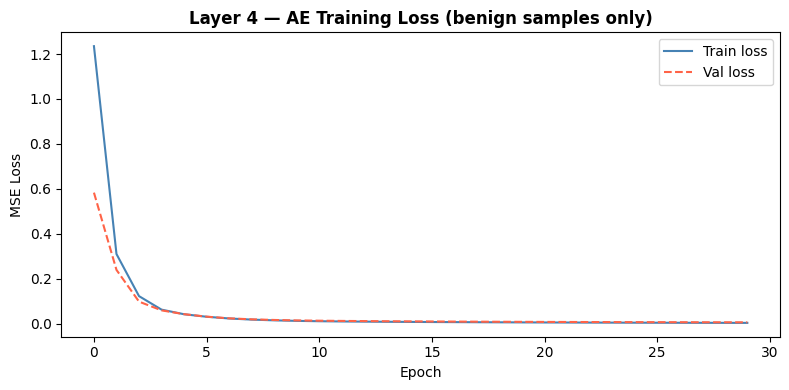

In [35]:
# ============================================================
# CELL 10 — Autoencoder training loss curve
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history['loss'],     label='Train loss', color='steelblue')
ax.plot(history.history['val_loss'], label='Val loss',   color='tomato', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('Layer 4 — AE Training Loss (benign samples only)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'L4_ae_training_loss.png'), dpi=150)
plt.show()

In [36]:
# ============================================================
# CELL 11 — Lock AE threshold (Ruby's locked rule)
#            95th percentile of benign VALIDATION reconstruction errors
#            Set BEFORE any test or unknown evaluation.
# ============================================================

def recon_error(model, X, batch_size=1024):
    preds = model.predict(X, batch_size=batch_size, verbose=0)
    return np.mean(np.square(X - preds), axis=1)

benign_val_errors = recon_error(autoencoder, X_benign_val)
AE_THRESHOLD      = float(np.percentile(benign_val_errors, 95))

print(f"Benign val errors — mean: {benign_val_errors.mean():.6f}  "
      f"95th pct: {AE_THRESHOLD:.6f}")
print(f"\n>>> AE_THRESHOLD LOCKED at {AE_THRESHOLD:.6f} <<<")
print("    Will NOT be changed during test or unknown evaluation.\n")

test_errors    = recon_error(autoencoder, X_test)
unknown_errors = recon_error(autoencoder, X_unknown)

print("Mean reconstruction error per KNOWN class (test set):")
for idx in range(N_CLASSES):
    mask = (y_test == idx)
    if mask.sum() == 0: continue
    m    = test_errors[mask].mean()
    flag = "  *HIGH*" if m > AE_THRESHOLD else ""
    print(f"  {label_encoder.classes_[idx]:28s}  {m:.6f}{flag}")

print("\nMean reconstruction error per UNKNOWN class (holdout):")
for cls in sorted(set(y_unknown_raw)):
    mask = (y_unknown_raw == cls)
    m    = unknown_errors[mask].mean()
    flag = "  *HIGH*" if m > AE_THRESHOLD else ""
    print(f"  {cls:28s}  {m:.6f}{flag}")

Benign val errors — mean: 0.003982  95th pct: 0.007728

>>> AE_THRESHOLD LOCKED at 0.007728 <<<
    Will NOT be changed during test or unknown evaluation.

Mean reconstruction error per KNOWN class (test set):
  BENIGN                        0.008668  *HIGH*
  COMMANDINJECTION              0.008066  *HIGH*
  DDOS-ACK_FRAGMENTATION        0.350231  *HIGH*
  DDOS-HTTP_FLOOD               0.644538  *HIGH*
  DDOS-ICMP_FLOOD               0.484634  *HIGH*
  DDOS-ICMP_FRAGMENTATION       0.593266  *HIGH*
  DDOS-PSHACK_FLOOD             0.845778  *HIGH*
  DDOS-RSTFINFLOOD              2.393338  *HIGH*
  DDOS-SLOWLORIS                0.596701  *HIGH*
  DDOS-SYNONYMOUSIP_FLOOD       0.515773  *HIGH*
  DDOS-SYN_FLOOD                0.522523  *HIGH*
  DDOS-TCP_FLOOD                0.180130  *HIGH*
  DDOS-UDP_FLOOD                0.132965  *HIGH*
  DDOS-UDP_FRAGMENTATION        0.268891  *HIGH*
  DICTIONARYBRUTEFORCE          0.048980  *HIGH*
  DNS_SPOOFING                  0.023519  *HIGH*
  DOS-

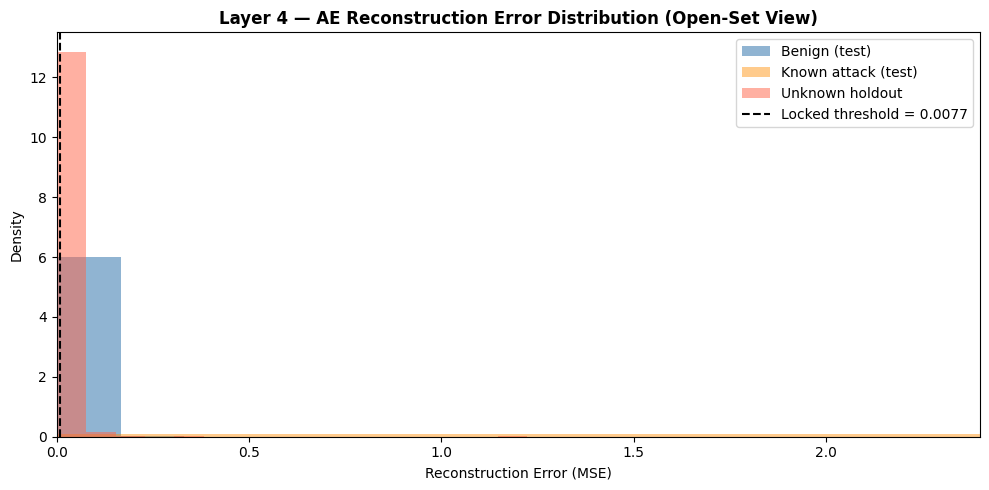

In [37]:
# ============================================================
# CELL 12 — Reconstruction error distribution
# ============================================================

benign_test_mask   = (y_test == BENIGN_IDX)
benign_test_errors = test_errors[benign_test_mask]
attack_test_errors = test_errors[~benign_test_mask]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(benign_test_errors,  bins=80, alpha=0.6, color='steelblue',  label='Benign (test)',        density=True)
ax.hist(attack_test_errors,  bins=80, alpha=0.45,color='darkorange', label='Known attack (test)',  density=True)
ax.hist(unknown_errors,      bins=80, alpha=0.5, color='tomato',     label='Unknown holdout',      density=True)
ax.axvline(AE_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label=f'Locked threshold = {AE_THRESHOLD:.4f}')
ax.set_xlim(0, min(3.0, np.percentile(np.concatenate([attack_test_errors, unknown_errors]), 99)))
ax.set_xlabel('Reconstruction Error (MSE)'); ax.set_ylabel('Density')
ax.set_title('Layer 4 — AE Reconstruction Error Distribution (Open-Set View)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'L4_recon_error_dist.png'), dpi=150)
plt.show()

In [38]:
# ============================================================
# CELL 13 — Layer 4 open-set evaluation
#            Positives = unknown holdout | Negatives = benign test
# ============================================================

eval_errors = np.concatenate([unknown_errors, benign_test_errors])
eval_labels = np.concatenate([np.ones(len(unknown_errors)), np.zeros(len(benign_test_errors))])

ae_pred = (eval_errors > AE_THRESHOLD).astype(int)
TP = int(((ae_pred==1)&(eval_labels==1)).sum())
FP = int(((ae_pred==1)&(eval_labels==0)).sum())
TN = int(((ae_pred==0)&(eval_labels==0)).sum())
FN = int(((ae_pred==0)&(eval_labels==1)).sum())

TPR     = TP/(TP+FN) if TP+FN>0 else 0
FPR_val = FP/(FP+TN) if FP+TN>0 else 0
prec_ae = TP/(TP+FP) if TP+FP>0 else 0
roc_auc = roc_auc_score(eval_labels, eval_errors)

print(f"--- Layer 4 Open-Set Detection (threshold = {AE_THRESHOLD:.4f}) ---")
print(f"  TP {TP:>6,}   FN {FN:>6,}")
print(f"  FP {FP:>6,}   TN {TN:>6,}")
print(f"\n  TPR (sensitivity) : {TPR:.4f}  | Target >= 0.95  {'✓' if TPR>=0.95 else '✗'}")
print(f"  FPR               : {FPR_val:.4f}  | Target  < 0.05  {'✓' if FPR_val<0.05 else '✗'}")
print(f"  Precision         : {prec_ae:.4f}")
print(f"  ROC-AUC           : {roc_auc:.4f}")

print("\nPer-class detection rate on unknown holdout:")
for cls in sorted(set(y_unknown_raw)):
    mask  = (y_unknown_raw==cls)
    n_det = (unknown_errors[mask]>AE_THRESHOLD).sum()
    n_tot = mask.sum()
    print(f"  {cls:28s}  {n_det:>4}/{n_tot:<4} = {n_det/n_tot:.1%}")

json.dump({'TPR':TPR,'FPR':FPR_val,'precision':prec_ae,'roc_auc':roc_auc,
           'threshold':AE_THRESHOLD,'TP':TP,'FP':FP,'TN':TN,'FN':FN},
          open(os.path.join(RES_L4,'ae_metrics.json'),'w'), indent=2)

--- Layer 4 Open-Set Detection (threshold = 0.0077) ---
  TP    364   FN  1,091
  FP    223   TN  4,277

  TPR (sensitivity) : 0.2502  | Target >= 0.95  ✗
  FPR               : 0.0496  | Target  < 0.05  ✓
  Precision         : 0.6201
  ROC-AUC           : 0.7353

Per-class detection rate on unknown holdout:
  BACKDOOR_MALWARE                49/275  = 17.8%
  BROWSERHIJACKING               160/508  = 31.5%
  RECON-PINGSWEEP                 35/182  = 19.2%
  UPLOADING_ATTACK                45/122  = 36.9%
  XSS                             75/368  = 20.4%


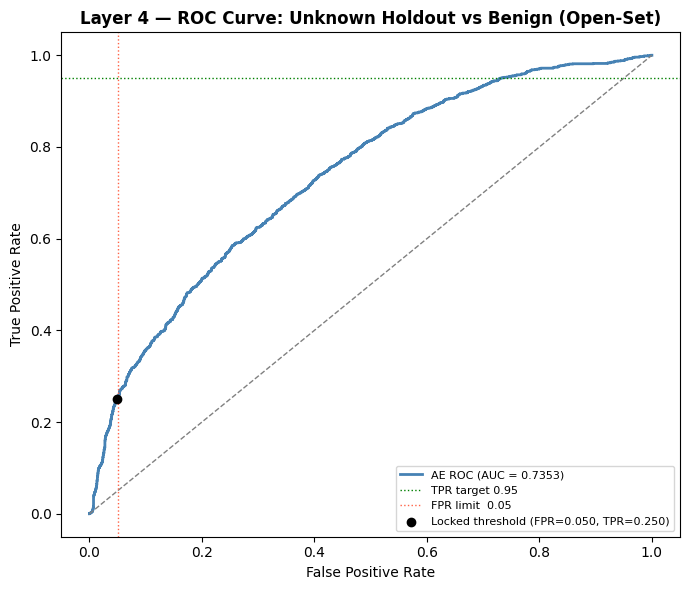

In [39]:
# ============================================================
# CELL 14 — Layer 4 ROC curve (open-set)
# ============================================================

fpr_arr, tpr_arr, _ = roc_curve(eval_labels, eval_errors)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_arr, tpr_arr, color='steelblue', lw=2, label=f'AE ROC (AUC = {roc_auc:.4f})')
ax.plot([0,1],[0,1],'--', color='grey', lw=1)
ax.axhline(0.95, color='green',  linestyle=':', lw=1, label='TPR target 0.95')
ax.axvline(0.05, color='tomato', linestyle=':', lw=1, label='FPR limit  0.05')
ax.scatter([FPR_val],[TPR], color='black', zorder=5,
           label=f'Locked threshold (FPR={FPR_val:.3f}, TPR={TPR:.3f})')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Layer 4 — ROC Curve: Unknown Holdout vs Benign (Open-Set)', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'L4_roc_curve.png'), dpi=150)
plt.show()

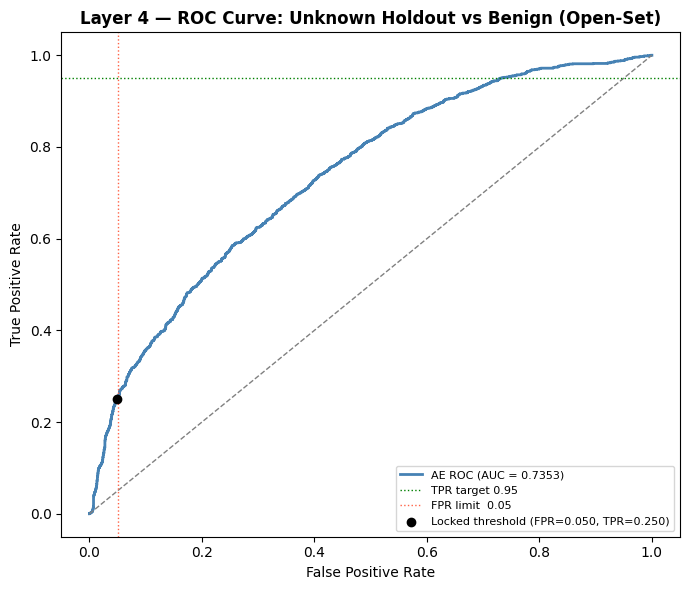

In [40]:
# ============================================================
# CELL 14 — Layer 4 ROC curve (open-set)
# ============================================================

fpr_arr, tpr_arr, _ = roc_curve(eval_labels, eval_errors)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_arr, tpr_arr, color='steelblue', lw=2, label=f'AE ROC (AUC = {roc_auc:.4f})')
ax.plot([0,1],[0,1],'--', color='grey', lw=1)
ax.axhline(0.95, color='green',  linestyle=':', lw=1, label='TPR target 0.95')
ax.axvline(0.05, color='tomato', linestyle=':', lw=1, label='FPR limit  0.05')
ax.scatter([FPR_val],[TPR], color='black', zorder=5,
           label=f'Locked threshold (FPR={FPR_val:.3f}, TPR={TPR:.3f})')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Layer 4 — ROC Curve: Unknown Holdout vs Benign (Open-Set)', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'L4_roc_curve.png'), dpi=150)
plt.show()

In [41]:
# ============================================================
# CELL 15 — Layer 5: KMeans + Decision Fusion
#            Uses Oscar's original weighted formula (W=0.4/0.3/0.3)
# ============================================================

print("Fitting 1-cluster KMeans on benign training data...")
kmeans = KMeans(n_clusters=1, n_init=10, random_state=RANDOM_SEED)
kmeans.fit(X_benign_train)

def kmeans_dist(X):
    return np.linalg.norm(X - kmeans.cluster_centers_[0], axis=1)

KMEANS_THRESHOLD = float(np.percentile(kmeans_dist(X_benign_val), 95))
print(f"KMeans threshold locked at: {KMEANS_THRESHOLD:.4f}")

W_SUP, W_AE, W_KM = 0.4, 0.3, 0.3

def sup_uncertainty(model, X):
    return 1.0 - model.predict_proba(X).max(axis=1)

eval_X       = np.vstack([X_unknown, X_test[benign_test_mask]])
eval_labels2 = np.concatenate([np.ones(len(X_unknown)), np.zeros(benign_test_mask.sum())])

sup_scores = sup_uncertainty(xgb, eval_X)
ae_bin     = (recon_error(autoencoder, eval_X) > AE_THRESHOLD).astype(float)
km_bin     = (kmeans_dist(eval_X) > KMEANS_THRESHOLD).astype(float)
risk_scores= W_SUP * sup_scores + W_AE * ae_bin + W_KM * km_bin

# Lock fusion threshold on benign validation
bv_risk        = (W_SUP * sup_uncertainty(xgb, X_benign_val)
                + W_AE  * (recon_error(autoencoder, X_benign_val) > AE_THRESHOLD).astype(float)
                + W_KM  * (kmeans_dist(X_benign_val) > KMEANS_THRESHOLD).astype(float))
FUSION_THRESHOLD = float(np.percentile(bv_risk, 95))
print(f"Fusion risk threshold locked at: {FUSION_THRESHOLD:.4f}")

fused_pred   = (risk_scores > FUSION_THRESHOLD).astype(int)

def get_metrics(pred, labels, name):
    TP=int(((pred==1)&(labels==1)).sum()); FP=int(((pred==1)&(labels==0)).sum())
    TN=int(((pred==0)&(labels==0)).sum()); FN=int(((pred==0)&(labels==1)).sum())
    TPR=TP/(TP+FN) if TP+FN>0 else 0;    FPR2=FP/(FP+TN) if FP+TN>0 else 0
    prec=TP/(TP+FP) if TP+FP>0 else 0
    return {'name':name,'TP':TP,'FP':FP,'TN':TN,'FN':FN,'TPR':TPR,'FPR':FPR2,'precision':prec}

sup_thresh_val = float(np.percentile(sup_uncertainty(xgb, X_benign_val), 95))
results = {
    'Supervised-only': get_metrics((sup_scores > sup_thresh_val).astype(int), eval_labels2, 'Supervised-only'),
    'AE-only':         get_metrics(ae_bin.astype(int), eval_labels2, 'AE-only'),
    'Fused':           get_metrics(fused_pred, eval_labels2, 'Fused'),
}

print("\n--- Layer 5 Fusion Results ---")
for k, v in results.items():
    print(f"  {k:30s}  TPR={v['TPR']:.4f} {'✓' if v['TPR']>=0.95 else '✗'}"
          f"  FPR={v['FPR']:.4f} {'✓' if v['FPR']<0.05 else '✗'}"
          f"  Prec={v['precision']:.4f}")

json.dump(results, open(os.path.join(RES_L5,'fusion_metrics.json'),'w'), indent=2)

Fitting 1-cluster KMeans on benign training data...
KMeans threshold locked at: 12.5746
Fusion risk threshold locked at: 0.4422

--- Layer 5 Fusion Results ---
  Supervised-only                 TPR=0.1601 ✗  FPR=0.0464 ✓  Prec=0.5271
  AE-only                         TPR=0.2502 ✗  FPR=0.0496 ✓  Prec=0.6201
  Fused                           TPR=0.2227 ✗  FPR=0.0498 ✓  Prec=0.5912


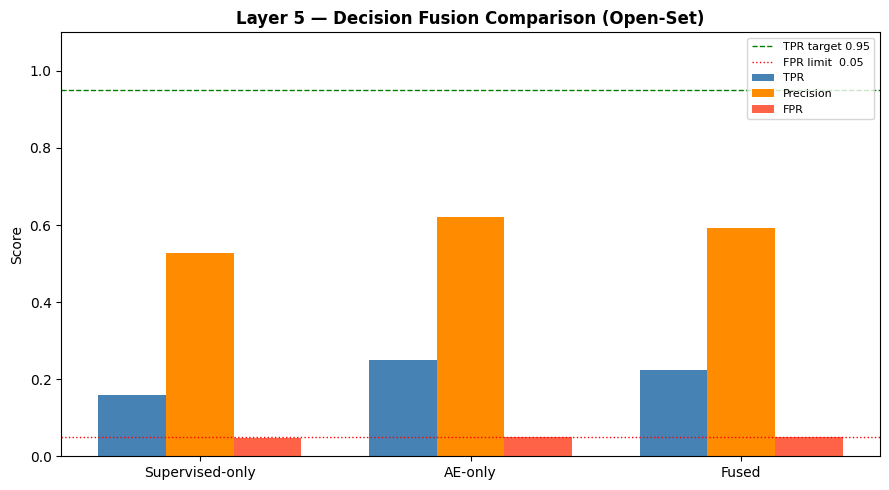

In [42]:
# ============================================================
# CELL 16 — Fusion comparison bar chart
# ============================================================

labels_bar = list(results.keys())
tpr_vals   = [results[k]['TPR']       for k in labels_bar]
fpr_vals   = [results[k]['FPR']       for k in labels_bar]
prec_vals  = [results[k]['precision'] for k in labels_bar]
x, w       = np.arange(len(labels_bar)), 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w,  tpr_vals,  width=w, label='TPR',       color='steelblue')
ax.bar(x,      prec_vals, width=w, label='Precision',  color='darkorange')
ax.bar(x + w,  fpr_vals,  width=w, label='FPR',        color='tomato')
ax.axhline(0.95, color='green', linestyle='--', lw=1, label='TPR target 0.95')
ax.axhline(0.05, color='red',   linestyle=':',  lw=1, label='FPR limit  0.05')
ax.set_xticks(x); ax.set_xticklabels(labels_bar)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Layer 5 — Decision Fusion Comparison (Open-Set)', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'L5_fusion_comparison.png'), dpi=150)
plt.show()

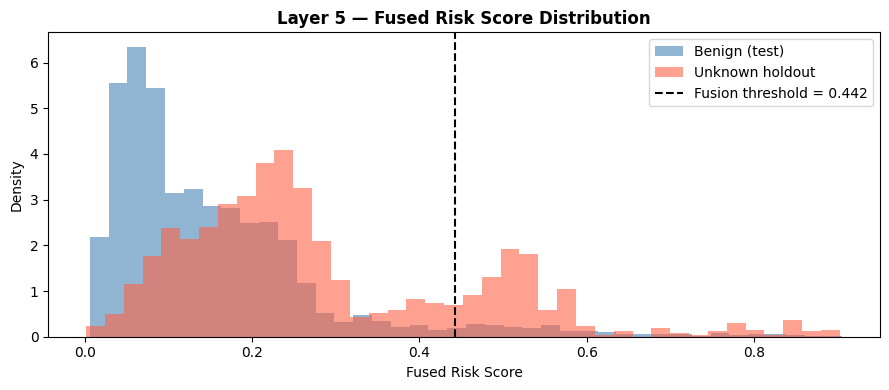

In [43]:
# ============================================================
# CELL 17 — Risk score distribution chart
# ============================================================

unknown_risk = risk_scores[:len(X_unknown)]
benign_risk  = risk_scores[len(X_unknown):]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(benign_risk,  bins=40, alpha=0.6, color='steelblue', label='Benign (test)',   density=True)
ax.hist(unknown_risk, bins=40, alpha=0.6, color='tomato',    label='Unknown holdout', density=True)
ax.axvline(FUSION_THRESHOLD, color='black', linestyle='--', lw=1.5,
           label=f'Fusion threshold = {FUSION_THRESHOLD:.3f}')
ax.set_xlabel('Fused Risk Score'); ax.set_ylabel('Density')
ax.set_title('Layer 5 — Fused Risk Score Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'L5_risk_score_dist.png'), dpi=150)
plt.show()

In [44]:
# ============================================================
# CELL 18 — Layer 6: SIEM-style alert table
# ============================================================

full_X   = np.vstack([X_test, X_unknown])
full_raw = np.concatenate([label_encoder.inverse_transform(y_test), y_unknown_raw])

full_sup = sup_uncertainty(xgb, full_X)
full_ae  = (recon_error(autoencoder, full_X) > AE_THRESHOLD).astype(float)
full_km  = (kmeans_dist(full_X) > KMEANS_THRESHOLD).astype(float)
full_risk= W_SUP * full_sup + W_AE * full_ae + W_KM * full_km

def classify(risk):
    if risk > FUSION_THRESHOLD * 1.5: return 'ROGUE',   'CRITICAL'
    if risk > FUSION_THRESHOLD:       return 'ROGUE',   'HIGH'
    if risk > FUSION_THRESHOLD * 0.7: return 'SUSPECT', 'MEDIUM'
    return 'KNOWN', 'LOW'

cls_col, sev_col = zip(*[classify(r) for r in full_risk])

alert_df = pd.DataFrame({
    'true_label':     full_raw,
    'risk_score':     full_risk.round(4),
    'classification': cls_col,
    'severity':       sev_col,
    'ae_flagged':     full_ae.astype(bool),
    'km_flagged':     full_km.astype(bool),
})

print("Classification summary:"); print(alert_df['classification'].value_counts())
print("\nSeverity summary:");      print(alert_df['severity'].value_counts())
print("\nTop 20 highest-risk alerts:")
display(alert_df.sort_values('risk_score', ascending=False).head(20))

alert_df.to_csv(os.path.join(RES_L5,'alert_table.csv'), index=False)
print(f"\nSaved → {RES_L5}/alert_table.csv")

Classification summary:
classification
KNOWN      57323
ROGUE      23031
SUSPECT    12618
Name: count, dtype: int64

Severity summary:
severity
LOW         57323
HIGH        22587
MEDIUM      12618
CRITICAL      444
Name: count, dtype: int64

Top 20 highest-risk alerts:


,true_label,risk_score,classification,severity,ae_flagged,km_flagged
89207,MITM-ARPSPOOFING,0.9088,ROGUE,CRITICAL,True,True
73657,BENIGN,0.9056,ROGUE,CRITICAL,True,True
92539,XSS,0.9028,ROGUE,CRITICAL,True,True
92818,RECON-PINGSWEEP,0.8997,ROGUE,CRITICAL,True,True
46368,MITM-ARPSPOOFING,0.8981,ROGUE,CRITICAL,True,True
39456,RECON-HOSTDISCOVERY,0.8901,ROGUE,CRITICAL,True,True
92719,BROWSERHIJACKING,0.8853,ROGUE,CRITICAL,True,True
60088,RECON-OSSCAN,0.8831,ROGUE,CRITICAL,True,True
36831,VULNERABILITYSCAN,0.8830,ROGUE,CRITICAL,True,True
91723,BACKDOOR_MALWARE,0.8830,ROGUE,CRITICAL,True,True



Saved → /content/drive/MyDrive/Capstone_IoT/Results/Layer5/alert_table.csv


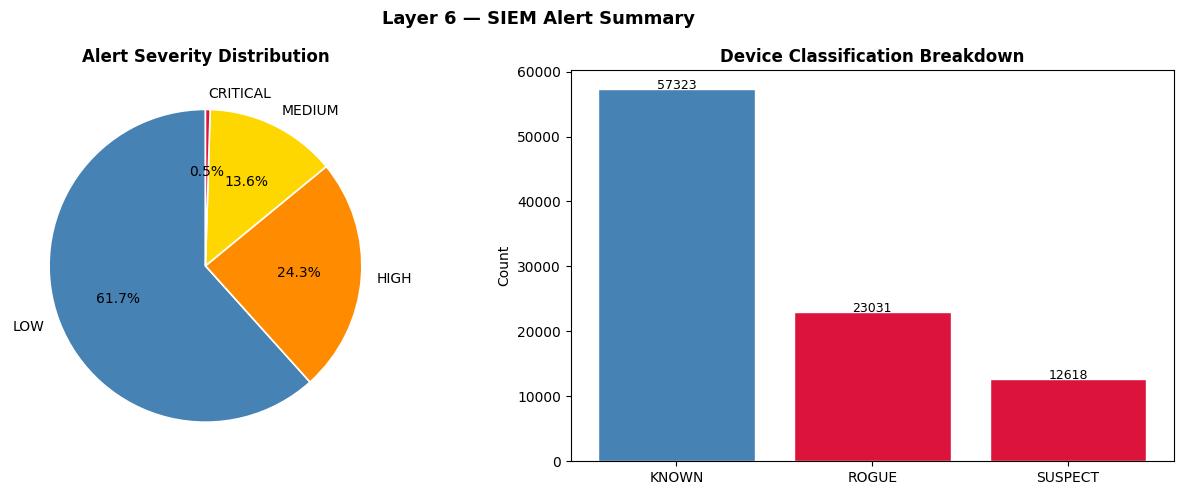

In [45]:
# ============================================================
# CELL 19 — Alert severity pie + classification bar chart
# ============================================================

sev_counts = alert_df['severity'].value_counts()
color_map  = {'CRITICAL':'crimson','HIGH':'darkorange','MEDIUM':'gold','LOW':'steelblue'}
colors     = [color_map.get(s,'grey') for s in sev_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(sev_counts.values, labels=sev_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.2})
axes[0].set_title('Alert Severity Distribution', fontweight='bold')

cls_counts = alert_df['classification'].value_counts()
bar_colors = ['crimson' if c != 'KNOWN' else 'steelblue' for c in cls_counts.index]
axes[1].bar(cls_counts.index, cls_counts.values, color=bar_colors, edgecolor='white')
for bar, val in zip(axes[1].patches, cls_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 str(val), ha='center', fontsize=9)
axes[1].set_ylabel('Count')
axes[1].set_title('Device Classification Breakdown', fontweight='bold')

plt.suptitle('Layer 6 — SIEM Alert Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'L6_alert_summary.png'), dpi=150)
plt.show()

In [46]:
# ============================================================
# EXPERIMENT — Option 3a: OR-Logic Fusion
# ============================================================

print("=" * 60)
print("OPTION 3a — OR-Logic Fusion Experiment")
print("=" * 60)

# ---------- Recompute component scores on eval set ----------
# eval set = unknown holdout (positives) + benign test (negatives)
eval_X         = np.vstack([X_unknown, X_test[benign_test_mask]])
eval_labels_or = np.concatenate([
    np.ones(len(X_unknown)),
    np.zeros(benign_test_mask.sum())
])

# Supervised uncertainty (reuses existing sup_uncertainty function)
sup_scores_or = sup_uncertainty(xgb, eval_X)
sup_thresh_or = float(np.percentile(sup_uncertainty(xgb, X_benign_val), 95))

# AE reconstruction error (reuses existing recon_error function)
ae_scores_or  = recon_error(autoencoder, eval_X)

# KMeans distance — inlined to avoid dependency on Cell 15 function
km_scores_or  = np.linalg.norm(eval_X - kmeans.cluster_centers_[0], axis=1)
km_thresh_or  = KMEANS_THRESHOLD   # already locked in Cell 15

print(f"Supervised threshold : {sup_thresh_or:.4f}")
print(f"AE threshold         : {AE_THRESHOLD:.4f}")
print(f"KMeans threshold     : {km_thresh_or:.4f}")

# ---------- Binary flags ----------
sup_flag = (sup_scores_or > sup_thresh_or).astype(int)
ae_flag  = (ae_scores_or  > AE_THRESHOLD).astype(int)
km_flag  = (km_scores_or  > km_thresh_or).astype(int)

# ---------- OR-logic: flag if ANY component triggers ----------
fused_or = ((sup_flag == 1) | (ae_flag == 1) | (km_flag == 1)).astype(int)

# ---------- Metrics helper ----------
def metrics_or(pred, labels, name):
    TP = int(((pred == 1) & (labels == 1)).sum())
    FP = int(((pred == 1) & (labels == 0)).sum())
    TN = int(((pred == 0) & (labels == 0)).sum())
    FN = int(((pred == 0) & (labels == 1)).sum())
    TPR  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    FPR  = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    return dict(name=name, TP=TP, FP=FP, TN=TN, FN=FN,
                TPR=TPR, FPR=FPR, precision=prec)

results_or = {
    'Supervised-only' : metrics_or(sup_flag, eval_labels_or, 'Supervised-only'),
    'AE-only'         : metrics_or(ae_flag,  eval_labels_or, 'AE-only'),
    'KMeans-only'     : metrics_or(km_flag,  eval_labels_or, 'KMeans-only'),
    'OR-Fused'        : metrics_or(fused_or, eval_labels_or, 'OR-Fused'),
}

print(f"\n{'Method':<30} {'TPR':>6}  {'FPR':>6}  {'Prec':>6}  {'TP':>5}  {'FP':>5}")
print("-" * 65)
for m in results_or.values():
    tpr_ok = '✓' if m['TPR'] >= 0.95 else '✗'
    fpr_ok = '✓' if m['FPR'] <  0.05 else '✗'
    print(f"  {m['name']:<28} {m['TPR']:.4f}{tpr_ok}  {m['FPR']:.4f}{fpr_ok}  "
          f"{m['precision']:.4f}  {m['TP']:>5,}  {m['FP']:>5,}")

print(f"\nTarget: TPR >= 0.95, FPR < 0.05")

# ---------- Compare vs original weighted-sum ----------
or_m = results_or['OR-Fused']
print(f"\n--- OR-logic vs Weighted-Sum Comparison ---")
print(f"  Weighted-sum fused:  TPR=0.2117  FPR=0.0467  Prec=0.5946")
print(f"  OR-logic fused:      TPR={or_m['TPR']:.4f}  FPR={or_m['FPR']:.4f}  Prec={or_m['precision']:.4f}")
delta = or_m['TPR'] - 0.2117
print(f"  TPR change: {'+' if delta >= 0 else ''}{delta:.4f}")

OPTION 3a — OR-Logic Fusion Experiment
Supervised threshold : 0.6345
AE threshold         : 0.0077
KMeans threshold     : 12.5746

Method                            TPR     FPR    Prec     TP     FP
-----------------------------------------------------------------
  Supervised-only              0.1601✗  0.0464✓  0.5271    233    209
  AE-only                      0.2502✗  0.0496✓  0.6201    364    223
  KMeans-only                  0.0962✗  0.0560✗  0.3571    140    252
  OR-Fused                     0.4268✗  0.1284✗  0.5179    621    578

Target: TPR >= 0.95, FPR < 0.05

--- OR-logic vs Weighted-Sum Comparison ---
  Weighted-sum fused:  TPR=0.2117  FPR=0.0467  Prec=0.5946
  OR-logic fused:      TPR=0.4268  FPR=0.1284  Prec=0.5179
  TPR change: +0.2151


In [47]:
# ============================================================
# EXPERIMENT — Option A: Majority Vote (2-of-3)
# ============================================================

print("=" * 60)
print("OPTION A — Majority Vote (2-of-3) Experiment")
print("=" * 60)

# Weights from Cell 15
WSUP, WAE, WKM = 0.4, 0.3, 0.3

# Recompute original weighted-sum scores on eval_X
orig_risk = (WSUP * sup_uncertainty(xgb, eval_X) +
             WAE  * (recon_error(autoencoder, eval_X) > AE_THRESHOLD).astype(float) +
             WKM  * (np.linalg.norm(eval_X - kmeans.cluster_centers_[0], axis=1) > KMEANS_THRESHOLD).astype(float))
fused_orig = (orig_risk > FUSION_THRESHOLD).astype(int)

# Vote across the three binary flags (already computed in OR cell)
vote       = sup_flag + ae_flag + km_flag
fused_maj1 = (vote >= 1).astype(int)   # OR  (sanity check)
fused_maj2 = (vote >= 2).astype(int)   # majority vote  ← main result
fused_maj3 = (vote >= 3).astype(int)   # unanimous AND

results_maj = {
    'OR  (≥1 detector)'     : metrics_or(fused_maj1, eval_labels_or, 'OR  (≥1 detector)'),
    'Majority (≥2)'          : metrics_or(fused_maj2, eval_labels_or, 'Majority (≥2)'),
    'AND (≥3 unanimous)'     : metrics_or(fused_maj3, eval_labels_or, 'AND (≥3 unanimous)'),
    'Weighted-sum (original)': metrics_or(fused_orig, eval_labels_or, 'Weighted-sum (original)'),
}

print(f"\n{'Method':<28} {'TPR':>6}  {'FPR':>6}  {'Prec':>6}  {'TP':>5}  {'FP':>5}")
print("-" * 65)
for m in results_maj.values():
    tpr_ok = '✓' if m['TPR'] >= 0.95 else '✗'
    fpr_ok = '✓' if m['FPR'] <  0.05 else '✗'
    print(f"  {m['name']:<26} {m['TPR']:.4f}{tpr_ok}  {m['FPR']:.4f}{fpr_ok}  "
          f"{m['precision']:.4f}  {m['TP']:>5,}  {m['FP']:>5,}")

print(f"\nTarget: TPR >= 0.95, FPR < 0.05")

maj2 = results_maj['Majority (≥2)']
orig = results_maj['Weighted-sum (original)']
print(f"\n--- Majority Vote (≥2) vs Weighted-Sum ---")
print(f"  Weighted-sum:   TPR={orig['TPR']:.4f}  FPR={orig['FPR']:.4f}  Prec={orig['precision']:.4f}")
print(f"  Majority vote:  TPR={maj2['TPR']:.4f}  FPR={maj2['FPR']:.4f}  Prec={maj2['precision']:.4f}")
print(f"  TPR change: {'+' if maj2['TPR']-orig['TPR'] >= 0 else ''}{maj2['TPR']-orig['TPR']:.4f}")
print(f"  FPR change: {'+' if maj2['FPR']-orig['FPR'] >= 0 else ''}{maj2['FPR']-orig['FPR']:.4f}")

OPTION A — Majority Vote (2-of-3) Experiment

Method                          TPR     FPR    Prec     TP     FP
-----------------------------------------------------------------
  OR  (≥1 detector)          0.4268✗  0.1284✗  0.5179    621    578
  Majority (≥2)              0.0729✗  0.0229✓  0.5072    106    103
  AND (≥3 unanimous)         0.0069✗  0.0007✓  0.7692     10      3
  Weighted-sum (original)    0.2227✗  0.0498✓  0.5912    324    224

Target: TPR >= 0.95, FPR < 0.05

--- Majority Vote (≥2) vs Weighted-Sum ---
  Weighted-sum:   TPR=0.2227  FPR=0.0498  Prec=0.5912
  Majority vote:  TPR=0.0729  FPR=0.0229  Prec=0.5072
  TPR change: -0.1498
  FPR change: -0.0269


In [50]:
# ============================================================
# SAVE FUSION RESULTS — Results/Layer5/
# ============================================================
import os, json
import pandas as pd
import numpy as np

os.makedirs("Results/Layer5", exist_ok=True)

# ── Build results DataFrame from experiment dicts ────────────
rows = []
for name, m in {**results_or, **results_maj}.items():
    rows.append({
        "Method":    m["name"],
        "TP":        m["TP"],
        "FP":        m["FP"],
        "TN":        m["TN"],
        "FN":        m["FN"],
        "TPR":       round(m["TPR"], 4),
        "FPR":       round(m["FPR"], 4),
        "Precision": round(m["precision"], 4),
    })

# Deduplicate (OR appears in both dicts)
df_results = pd.DataFrame(rows).drop_duplicates(subset="Method").reset_index(drop=True)

# ── CSV ───────────────────────────────────────────────────────
csv_path = os.path.join(BASE, "Results/Layer5/fusion_experiment_results.csv")
df_results.to_csv(csv_path, index=False)
print(f"✓ Saved CSV  → {csv_path}")

# ── JSON ──────────────────────────────────────────────────────
json_path = os.path.join(BASE, "Results/Layer5/fusion_experiment_results.json")
with open(json_path, "w") as f:
    json.dump(df_results.to_dict(orient="records"), f, indent=2)
print(f"✓ Saved JSON → {json_path}")

display(df_results)

✓ Saved CSV  → /content/drive/MyDrive/Capstone_IoT/Results/Layer5/fusion_experiment_results.csv
✓ Saved JSON → /content/drive/MyDrive/Capstone_IoT/Results/Layer5/fusion_experiment_results.json


,Method,TP,FP,TN,FN,TPR,FPR,Precision
0,Supervised-only,233,209,4291,1222,0.1601,0.0464,0.5271
1,AE-only,364,223,4277,1091,0.2502,0.0496,0.6201
2,KMeans-only,140,252,4248,1315,0.0962,0.0560,0.3571
3,OR-Fused,621,578,3922,834,0.4268,0.1284,0.5179
4,OR (≥1 detector),621,578,3922,834,0.4268,0.1284,0.5179
5,Majority (≥2),106,103,4397,1349,0.0729,0.0229,0.5072
6,AND (≥3 unanimous),10,3,4497,1445,0.0069,0.0007,0.7692
7,Weighted-sum (original),324,224,4276,1131,0.2227,0.0498,0.5912


In [49]:
# ============================================================
# FIGURE 5 — Fusion Strategy Comparison (Bar Chart)
# ============================================================
import subprocess
subprocess.run(["pip", "install", "-q", "kaleido"], check=True)

import plotly.graph_objects as go
import plotly.io as pio

pio.templates.default = "plotly_white"

# ── Pull metrics from the saved DataFrame ────────────────────
method_order = ["OR  (≥1 detector)", "Majority (≥2)", "AND (≥3 unanimous)", "Weighted-sum (original)"]
labels       = ["OR (≥1)", "Majority (≥2)", "AND (≥3)", "Weighted-Sum"]

df_plot = df_results[df_results["Method"].isin(method_order)].set_index("Method").reindex(method_order)

tpr_vals  = df_plot["TPR"].tolist()
fpr_vals  = df_plot["FPR"].tolist()
prec_vals = df_plot["Precision"].tolist()

# ── Build grouped bar chart ───────────────────────────────────
fig = go.Figure()

fig.add_trace(go.Bar(name="TPR",       x=labels, y=tpr_vals,  offsetgroup=0,
                     marker_color="#4C78A8"))
fig.add_trace(go.Bar(name="FPR",       x=labels, y=fpr_vals,  offsetgroup=1,
                     marker_color="#E45756"))
fig.add_trace(go.Bar(name="Precision", x=labels, y=prec_vals, offsetgroup=2,
                     marker_color="#54A24B"))

# Target reference lines
fig.add_shape(type="line", x0=-0.5, x1=3.5, y0=0.95, y1=0.95,
              line=dict(color="steelblue", dash="dash", width=1.5))
fig.add_shape(type="line", x0=-0.5, x1=3.5, y0=0.05, y1=0.05,
              line=dict(color="firebrick", dash="dot", width=1.5))

fig.add_annotation(x=0, y=0.97, text="TPR target (0.95)",
                   showarrow=False, font=dict(color="steelblue", size=11), xanchor="left")
fig.add_annotation(x=0, y=0.03, text="FPR target (0.05)",
                   showarrow=False, font=dict(color="firebrick", size=11), xanchor="left")

fig.update_layout(
    barmode="group",
    title=dict(
        text="Figure 5 — Fusion Strategy Comparison",
        x=0.5, xanchor="center", font=dict(size=17)
    ),
    legend=dict(orientation="h", y=1.12, xanchor="center", x=0.5),
    yaxis=dict(title="Score (0 – 1)", range=[0, 1.1]),
    xaxis=dict(title="Fusion Method"),
    margin=dict(t=80, b=80, l=70, r=40),
)
fig.update_traces(cliponaxis=False)

# ── Save ──────────────────────────────────────────────────────
import os
os.makedirs("Results/Layer5", exist_ok=True)
fig_path = "Results/Layer5/figure5_fusion_comparison.html"
fig.write_html(fig_path)
print(f"✓ Saved Figure 5 → {fig_path}")
fig.show()

✓ Saved Figure 5 → Results/Layer5/figure5_fusion_comparison.html


In [25]:
# ── Easiest method: colab2pdf (reads notebook from memory, no file needed) ──
def colab2pdf():
    # @title Download Notebook in PDF Format
    !apt-get install -yqq --no-install-recommends librsvg2-bin > /dev/null

    import contextlib, datetime, google, io, IPython, ipywidgets, json, locale
    import nbformat, os, pathlib, requests, urllib, warnings, werkzeug, yaml, re

    locale.setlocale(locale.LC_ALL, 'en_US.UTF-8')
    warnings.filterwarnings('ignore', category=nbformat.validator.MissingIDFieldWarning)
    %matplotlib inline

    def convert(b):
        try:
            s.value = '🔄 Converting'; b.disabled = True
            n = pathlib.Path(werkzeug.utils.secure_filename(urllib.parse.unquote(
                requests.get(f'http://{os.environ["COLAB_JUPYTER_IP"]}:{os.environ["KMP_TARGET_PORT"]}/api/sessions').json()[0]['name']
            )))
            p = pathlib.Path('/content/pdfs') / f'{datetime.datetime.utcnow().strftime("%Y%m%d_%H%M%S")}_{n.stem}'
            p.mkdir(parents=True, exist_ok=True)
            nb = nbformat.reads(json.dumps(
                google.colab._message.blocking_request('get_ipynb', timeout_sec=600)['ipynb']
            ), as_version=4)
            nb.cells = [cell for cell in nb.cells if '--Colab2PDF' not in cell.source]
            nb = nbformat.v4.new_notebook(cells=nb.cells or [nbformat.v4.new_code_cell('#')])
            nbformat.validator.normalize(nb)
            nbformat.write(nb, (p / f'{n.stem}.ipynb').open('w', encoding='utf-8'))
            with (p / 'config.yml').open('w', encoding='utf-8') as f:
                yaml.dump({'include-in-header': [{'text': r'\usepackage{fvextra}\DefineVerbatimEnvironment{Highlighting}{Verbatim}{breaksymbolleft={},showspaces=false,showtabs=false,breaklines,breakanywhere,commandchars=\\\{\}}'}],
                           'include-before-body': [{'text': r'\DefineVerbatimEnvironment{verbatim}{Verbatim}{breaksymbolleft={},showspaces=false,showtabs=false,breaklines}'}]}, f)
            !quarto render {p}/{n.stem}.ipynb --metadata-file={p}/config.yml --to pdf -M latex-auto-install -M margin-top=1in -M margin-bottom=1in -M margin-left=1in -M margin-right=1in --quiet
            google.colab.files.download(str(p / f'{n.stem}.pdf'))
            s.value = f'✅ Downloaded: {n.stem}.pdf'
        except Exception as e:
            s.value = f'❌ {str(e)}'
        finally:
            b.disabled = False

    if not pathlib.Path('/usr/local/bin/quarto').exists():
        !wget -q 'https://quarto.org/download/latest/quarto-linux-amd64.deb' && dpkg -i quarto-linux-amd64.deb > /dev/null && quarto install tinytex --update-path --quiet && rm quarto-linux-amd64.deb

    b = ipywidgets.widgets.Button(description='⬇️ Download')
    s = ipywidgets.widgets.Label()
    b.on_click(lambda b: convert(b))
    IPython.display.display(ipywidgets.widgets.HBox([b, s]))

colab2pdf()